# The code behind it: histograms, skew & the IQR rule in code

*Part 1 · Lesson 2 · the code behind it  ·  data: Old Faithful · Lending Club (same as Lesson 2)*

*↩ A companion to [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb).*

**↩ Back:** [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](02-distributions-shape-outliers~another-dataset.ipynb)

**In Lesson 2 you read shape off the data with one-liners** — `e.skew()`, `income.quantile([.25, .75])`,
`ax.hist(...)`. They worked like magic words. This companion **opens the hood**: you'll build a frequency
table, draw a histogram from raw bar counts, compute skewness from its formula, and find the outlier fence
yourself — so "skew" and "the IQR rule" stop being methods you call and become a few lines of code you
understand.

Same two datasets, same final numbers — but the focus shifts from *what the shape means* to **how you
compute it in Python**. We'll go in the order a programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load it, look at its shape, select a column and a row mask.
3. **Build it step by step** — turn the frequency table, the histogram, the skew formula and the IQR fence into NumPy, and check each against the library.
4. **The idiom** — counting with a vectorized boolean mask vs. a Python loop, and binning with `pd.cut` / `np.digitize`.
5. **Refactor into a function** — wrap the fence as your own reusable `flag_outliers()`.
6. **Now you code** — write-it-yourself exercises.
7. **What you learned** — the coding *and* the statistics.

You don't need Lesson 2 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have built the three tools Lesson 2 used to read the *shape* of data:
a **frequency table** (and the histogram that draws it), a **skewness** number from its formula, and the
**1.5 × IQR outlier fence** — then wrapped that fence as your own reusable function. Nothing here needs new
statistics; everything is the Python *underneath* the one-liners you already ran.

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **pandas** | tables (`DataFrame`) and columns (`Series`) | loading the CSVs, selecting, quantiles |
| **NumPy** | fast math on whole arrays at once | counting bins, the skew formula, the fences |
| **matplotlib** | plotting | a histogram we draw ourselves with `ax.bar` |
| **SciPy** | a scientific toolbox | one trusted `skew()` to check ours against |

A **`DataFrame`** is a spreadsheet in code: named columns, numbered rows. A single column is a **`Series`** —
an array of values with an index. Almost everything below is "do some arithmetic to a whole Series at once."

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

# The SAME two datasets as the core lesson:
faithful = sl.load_csv('faithful.csv',
                       url='https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv')
loans = sl.load_csv('loans.csv',
                    url='https://www.openintro.org/data/csv/loans_full_schema.csv')

print(f'Old Faithful: a {type(faithful).__name__} with shape {faithful.shape}  (rows, columns)')
print(f'Lending Club: shape {loans.shape}')

Old Faithful: a DataFrame with shape (272, 3)  (rows, columns)
Lending Club: shape (10000, 55)


## 2) The data in code

Before any statistics, a programmer *interrogates the object*: what type is it, how big is it, what are the
columns, what do the first rows look like? Four habits worth keeping:

- `.shape` → `(rows, columns)` as a tuple.
- `.columns` → the column names.
- `.dtypes` → the **type** of each column (`float64` = decimal number, `int64` = whole number, `object` = text).
- `.head()` → the first few rows, to eyeball it.

In [2]:
print('shape  :', faithful.shape)
print('columns:', list(faithful.columns))
print('\ndtypes (the type stored in each column):')
print(faithful.dtypes)
faithful.head()

shape  : (272, 3)
columns: ['rownames', 'eruptions', 'waiting']

dtypes (the type stored in each column):
rownames       int64
eruptions    float64
waiting        int64
dtype: object


,rownames,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85


### Selecting a column and a row mask

- **One column** → `faithful['eruptions']` gives a `Series` of eruption lengths in minutes.
- **A boolean mask** → `e > 3` makes a column of `True`/`False`; the **mean of a True/False column is just the
  proportion that are `True`**, and `.sum()` counts them. This filter-and-count pattern is the single most
  useful idiom in pandas, and we'll lean on it for outliers later.

In [3]:
e = faithful['eruptions']                  # eruption length, minutes — a Series
print('e is a', type(e).__name__, 'of', len(e), 'values; first 5:')
print(e.head().to_list())

# A boolean mask in action: the "long" eruptions.
long_mask = e > 3
print(f'\neruptions longer than 3 min: {long_mask.sum()} of {len(e)}  ({long_mask.mean()*100:.0f}%)')
print('(.sum() counts the Trues; .mean() turns them into a proportion.)')

e is a Series of 272 values; first 5:
[3.6, 1.8, 3.333, 2.283, 4.533]

eruptions longer than 3 min: 175 of 272  (64%)
(.sum() counts the Trues; .mean() turns them into a proportion.)


## 3) Build it step by step

Now the heart of it. Each tool is a one-line library call *and* a short formula — we'll write the formula in
NumPy and check the two agree. Once you've built it, the library call is no longer a mystery box.

### A frequency table from scratch

A **frequency table** chops the number line into equal slices ("bins") and counts how many values fall in
each. First we *choose the bin edges* (here, every half-minute), then count. `np.histogram` does the counting
for us — and it's worth seeing it return exactly the same tallies as pandas' `pd.cut(...).value_counts()`.

In [4]:
edges = np.arange(1.5, 5.5 + 0.5, 0.5)          # bin edges every half-minute: 1.5, 2.0, ..., 5.5
print('bin edges:', edges)

counts, _ = np.histogram(e, bins=edges)         # how many eruptions land in each bin
print('counts (np.histogram):', counts, '  total =', counts.sum())

# The pandas way to the SAME tallies, as a labelled table:
table = pd.cut(e, bins=edges, right=False).value_counts().sort_index()
print('\ncounts (pd.cut):', table.to_list(), '  total =', int(table.sum()))
print('same counts?', np.array_equal(counts, table.to_numpy()))

freq = table.rename('count').to_frame()
freq['bar'] = freq['count'].apply(lambda c: '#' * c)   # a tiny text histogram
print('\n' + freq.to_string())

bin edges: [1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5]
counts (np.histogram): [51 41  5  7 30 73 61  4]   total = 272

counts (pd.cut): [51, 41, 5, 7, 30, 73, 61, 4]   total = 272
same counts? True

            count                                                                        bar
eruptions                                                                                   
[1.5, 2.0)     51                        ###################################################
[2.0, 2.5)     41                                  #########################################
[2.5, 3.0)      5                                                                      #####
[3.0, 3.5)      7                                                                    #######
[3.5, 4.0)     30                                             ##############################
[4.0, 4.5)     73  #########################################################################
[4.5, 5.0)     61              ################################

Look at the `bar` column: two crowds, a cluster of short eruptions near 2 minutes and a bigger cluster of long
ones near 4 to 4.5, separated by a near-empty valley around 3. A distribution with two peaks like this is
**bimodal** ("two modes") — and the table already shows it before we draw a single bar.

### A histogram is just bars over that table

A histogram is *nothing more* than a bar chart of the frequency table. To prove it, we won't call `ax.hist`
— we'll draw the bars ourselves with `ax.bar`, one bar per bin, as tall as that bin's count. The bin
**centers** sit halfway between consecutive edges, and the **width** is the gap between edges.

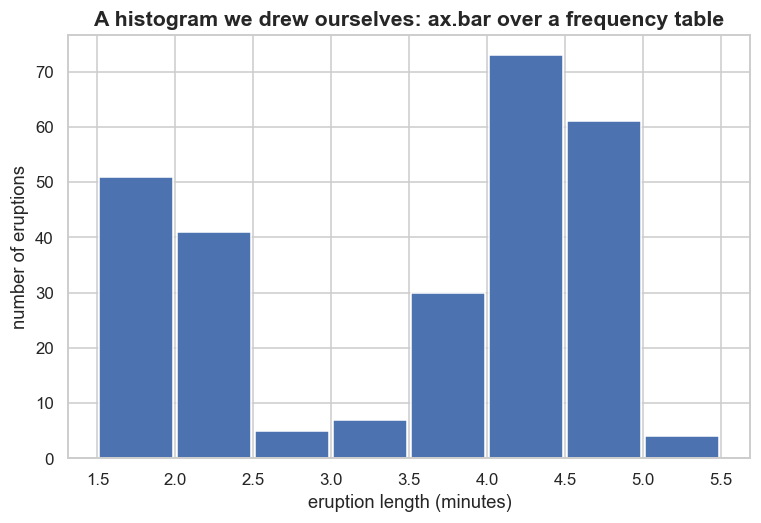

Each bar is one row of the frequency table. ax.hist() just does the
count-then-bar for you in one call — there is no magic underneath.


In [5]:
centers = (edges[:-1] + edges[1:]) / 2          # midpoint of each bin
width   = np.diff(edges)                        # bin widths (all 0.5 here)

fig, ax = plt.subplots()
ax.bar(centers, counts, width=width * 0.95, color='#4c72b0', edgecolor='white')
ax.set_xlabel('eruption length (minutes)'); ax.set_ylabel('number of eruptions')
ax.set_title('A histogram we drew ourselves: ax.bar over a frequency table')
plt.show()

print('Each bar is one row of the frequency table. ax.hist() just does the')
print('count-then-bar for you in one call — there is no magic underneath.')

### Skew, from its formula

Now switch to **Lending Club** incomes — a textbook **right skew** (most people cluster low, a long tail of
high earners stretches right). **Skewness** is the *third standardized moment*: standardize each value to a
z-score, cube it, average. Cubing keeps the sign, so values far out on one side dominate and decide which way
it tips:

$$\text{skew} = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{\sigma}\right)^3.$$

That $\sigma$ uses the **population** SD (`std(ddof=0)`, divide by $n$). `scipy.stats.skew` uses the very same
definition, so the two should match to many decimals.

In [6]:
income = loans['annual_income']                 # dollars, self-reported
x = income.to_numpy()

skew_by_hand = np.mean(((x - x.mean()) / x.std(ddof=0)) ** 3)   # the formula, verbatim
skew_scipy   = stats.skew(x)

print(f'skew by hand        : {skew_by_hand:.6f}')
print(f'scipy.stats.skew(x) : {skew_scipy:.6f}')
print('match?', np.isclose(skew_by_hand, skew_scipy))
print(f'\n-> skew = {skew_by_hand:.2f}: a big positive number means a long RIGHT tail.')
print(f'   (mean ${income.mean():,.0f} sits well above median ${income.median():,.0f} — the tail drags the mean up.)')

# A friendly footnote: pandas' Series.skew() applies a small sample-size bias
# correction, so it comes out a hair different. Same idea, slightly different number.
print(f'\npandas income.skew(): {income.skew():.6f}  (bias-corrected, so it differs slightly — that is fine)')

skew by hand        : 9.033136
scipy.stats.skew(x) : 9.033136
match? True

-> skew = 9.03: a big positive number means a long RIGHT tail.
   (mean $79,222 sits well above median $65,000 — the tail drags the mean up.)

pandas income.skew(): 9.034492  (bias-corrected, so it differs slightly — that is fine)


### The 1.5 × IQR outlier fence, from the formula

How far is "too far" out in the tail? The standard automatic flag uses the **IQR** (interquartile range, the
width of the middle 50%). With quartiles $Q_1$ (25th percentile) and $Q_3$ (75th percentile):

$$\text{IQR} = Q_3 - Q_1, \qquad \text{lower fence} = Q_1 - 1.5\,\text{IQR}, \qquad \text{upper fence} = Q_3 + 1.5\,\text{IQR}.$$

`np.percentile` and pandas' `Series.quantile` both give the quartiles (and should agree). Then the fences are
plain arithmetic, and a **boolean mask** flags anything past them.

In [7]:
q1_np, q3_np = np.percentile(x, [25, 75])           # NumPy way
q1_pd, q3_pd = income.quantile([0.25, 0.75])        # pandas way
print(f'Q1: np.percentile = ${q1_np:,.0f}   Series.quantile = ${q1_pd:,.0f}   match? {np.isclose(q1_np, q1_pd)}')
print(f'Q3: np.percentile = ${q3_np:,.0f}   Series.quantile = ${q3_pd:,.0f}   match? {np.isclose(q3_np, q3_pd)}')

iqr = q3_np - q1_np
lower_fence = q1_np - 1.5 * iqr
upper_fence = q3_np + 1.5 * iqr
print(f'\nIQR = ${iqr:,.0f}')
print(f'lower fence Q1 - 1.5*IQR = ${lower_fence:,.0f}')
print(f'upper fence Q3 + 1.5*IQR = ${upper_fence:,.0f}')

outlier_mask = (income < lower_fence) | (income > upper_fence)   # the filter-and-count idiom
print(f'\noutliers flagged: {outlier_mask.sum():,} of {len(income):,}  ({outlier_mask.mean()*100:.1f}%)')
print(f'  ... all on the high side: {(income > upper_fence).sum():,} above, {(income < lower_fence).sum():,} below')

Q1: np.percentile = $45,000   Series.quantile = $45,000   match? True
Q3: np.percentile = $95,000   Series.quantile = $95,000   match? True

IQR = $50,000
lower fence Q1 - 1.5*IQR = $-30,000
upper fence Q3 + 1.5*IQR = $170,000

outliers flagged: 508 of 10,000  (5.1%)
  ... all on the high side: 508 above, 0 below


The fence lands at **170,000 dollars** and flags **508** borrowers (~5%) — every one of them a genuine high earner,
not a data error. The lower fence is *negative* (about -30,000 dollars), so nobody can fall below it; with right-skewed
money data the rule fires only on the long high side.

## 4) The idiom — a mask vs. a loop, and binning

### Counting outliers: vectorized mask vs. a Python loop

You *could* count the outliers with a Python `for` loop. It gives the same answer but is slower and noisier to
read. Compare the two — the vectorized boolean mask is the idiom you want.

In [8]:
# The loop way (how you might first think of it):
count_loop = 0
for v in income:
    if v < lower_fence or v > upper_fence:
        count_loop += 1

# The vectorized way (what NumPy/pandas is for): a True/False column, summed.
count_vec = ((income < lower_fence) | (income > upper_fence)).sum()

print(f'loop count       : {count_loop:,}')
print(f'vectorized count : {count_vec:,}   <- same number, one line, and far faster on big data')
print('match?', count_loop == count_vec)

loop count       : 508
vectorized count : 508   <- same number, one line, and far faster on big data
match? True


### Binning: which bin does each value fall in?

Two ways to assign every value to a bin, both from the edges we already chose. `pd.cut` gives a **labelled
category** per value (great for tables); `np.digitize` gives a plain **integer index** per value (great for
math). Picking the right one is the idiom.

In [9]:
# pd.cut: each eruption labelled with its half-minute interval, then counted.
cut_counts = pd.cut(e, bins=edges, right=False).value_counts().sort_index()
print('pd.cut bin counts :', cut_counts.to_list())

# np.digitize: each eruption gets the index (1..8) of the bin it lands in.
bin_index = np.digitize(e, edges)
idx_counts = [int((bin_index == k).sum()) for k in range(1, len(edges))]
print('np.digitize counts:', idx_counts)
print('same tallies as the frequency table?', idx_counts == cut_counts.to_list())

pd.cut bin counts : [51, 41, 5, 7, 30, 73, 61, 4]
np.digitize counts: [51, 41, 5, 7, 30, 73, 61, 4]
same tallies as the frequency table? True


## 5) Refactor into a reusable function

You computed Q1, Q3, the IQR and the two fences once for income. The programmer's reflex is to **wrap repeated
work in a function**: name it, give it inputs, `return` the result. Then "flag the outliers" is one call you
can reuse on *any* numeric column — and the `k=1.5` is a parameter you can dial.

In [10]:
def flag_outliers(series, k=1.5):
    '''Return (lower_fence, upper_fence, mask) for the k*IQR rule on a numeric Series.

    The mask is a boolean Series: True where the value is past either fence.
    Pass a larger k (e.g. 3.0) for a stricter "far out" flag.
    '''
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return lower, upper, mask

# Reuse it on income — should reproduce the Section-3 numbers exactly:
lo, hi, mask = flag_outliers(income)
print(f'income : fence (${lo:,.0f}, ${hi:,.0f})  ->  {mask.sum():,} outliers')

# ... and on a totally different column, no copy-paste of the formula:
lo2, hi2, mask2 = flag_outliers(loans['interest_rate'])
print(f'interest_rate : fence ({lo2:.2f}%, {hi2:.2f}%)  ->  {mask2.sum():,} outliers')

# Dial k up to 3.0 — a stricter "really far out" flag finds fewer:
lo3, hi3, mask3 = flag_outliers(income, k=3.0)
print(f'income (k=3.0) : fence (${lo3:,.0f}, ${hi3:,.0f})  ->  {mask3.sum():,} outliers')

income : fence ($-30,000, $170,000)  ->  508 outliers
interest_rate : fence (1.00%, 23.48%)  ->  364 outliers
income (k=3.0) : fence ($-105,000, $245,000)  ->  187 outliers


A function is a contract: *give me a Series (and maybe a `k`), I'll give you the fences and a mask of who's
past them.* Once it's correct, you stop thinking about quartiles and start thinking in **columns and flags** —
exactly the leap from "writing statistics" to "doing statistics in code."

## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — predict the answer
before you run it.

1. **Your own frequency table.** Pick bin edges for income with `edges = np.arange(0, 250_000 + 25_000, 25_000)`
   and count with `np.histogram(income, bins=edges)`. Which bin is tallest? Predict it from the median, then
   check.

2. **Skew, with a twist.** Compute the skew of `e` (Old Faithful eruptions) with the from-scratch formula and
   compare to `stats.skew(e)`. The number is small and near zero — explain *why*, using the bimodal frequency
   table from Section 3.

3. **A robust spread.** Write `iqr(series)` returning `Q3 − Q1` from `series.quantile([0.25, 0.75])`. Test it on
   `income` and confirm it matches the `iqr` you computed in Section 3.

4. **Reuse the fence.** Call `flag_outliers(loans['debt_to_income'])` and print how many rows it flags. Then try
   `k=1.5` vs `k=3.0` — does the stricter fence flag fewer? (It should.)

## What you learned

**Coding**
- A `DataFrame` is a table; a column is a `Series`. Interrogate any new data with `.shape`, `.columns`,
  `.dtypes`, `.head()`.
- A **histogram is just bars over a frequency table** — `np.histogram` (or `pd.cut(...).value_counts()`) does the
  counting, and `ax.bar` over those counts draws what `ax.hist` would.
- **Boolean masks** (`(s < lo) | (s > hi)`) filter and count; the **mean of a True/False column is a proportion**.
- **Vectorization** replaces loops — counting outliers with one masked expression is the same answer as a `for`
  loop, but cleaner and far faster.
- `pd.cut` labels each value with its bin; `np.digitize` gives an integer bin index — same tallies, different uses.
- **Refactor repeated work into a function** with clear inputs, a docstring and a `return`, then reuse it everywhere.

**Statistics (now demystified)**
- A **frequency table** is just bin edges plus counts; its *pattern* is the distribution's shape (Old Faithful is
  **bimodal**).
- **Skewness** is the average cubed z-score (the third standardized moment); you reproduced SciPy's value to many
  decimals. A big positive skew (income ≈ **9.0**) means a long right tail. (pandas' `Series.skew()` adds a small
  sample-size bias correction, so it differs by a hair — both are right.)
- Use **`ddof=0`** (divide by $n$) for the population SD inside the skew formula; that's the definition SciPy uses.
- The **1.5 × IQR rule** flags points past $Q_1 - 1.5\,\text{IQR}$ or $Q_3 + 1.5\,\text{IQR}$. For income the upper
  fence is **170,000 dollars** and it flags **508** real high earners — a "look here" flag, not proof of an error.

**Back to the core lesson** ([Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb))
for the *meaning* of these numbers, or read on through the course.

---

**↩ Back to the lesson:** [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](02-distributions-shape-outliers~another-dataset.ipynb)